# LED Wall Preview

Unified notebook to preview all plugins, icons, elements, and composed scenes.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib ipympl

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from ledwall_server.plugins.bitcoin import Bitcoin
from ledwall_server.plugins.clock import Clock
from ledwall_server.plugins.effect import ColorCycle, Rainbow, SolidColor
from ledwall_server.plugins.elements import (
    BarElement,
    IconElement,
    RectElement,
    TextElement,
)
from ledwall_server.plugins.icons import ICONS
from ledwall_server.plugins.screen import Screen
from ledwall_server.plugins.text import ScrollingText, StaticText
from ledwall_server.plugins.weather import Weather
from ledwall_server.renderer import Renderer
from picow_ws2812_devtools.visualizer import LedWallVisualizer

In [3]:
W, H = 32, 8
viz = LedWallVisualizer(width=W, height=H)

## Icon Gallery

All 7x7 bitmap icons available for plugins.

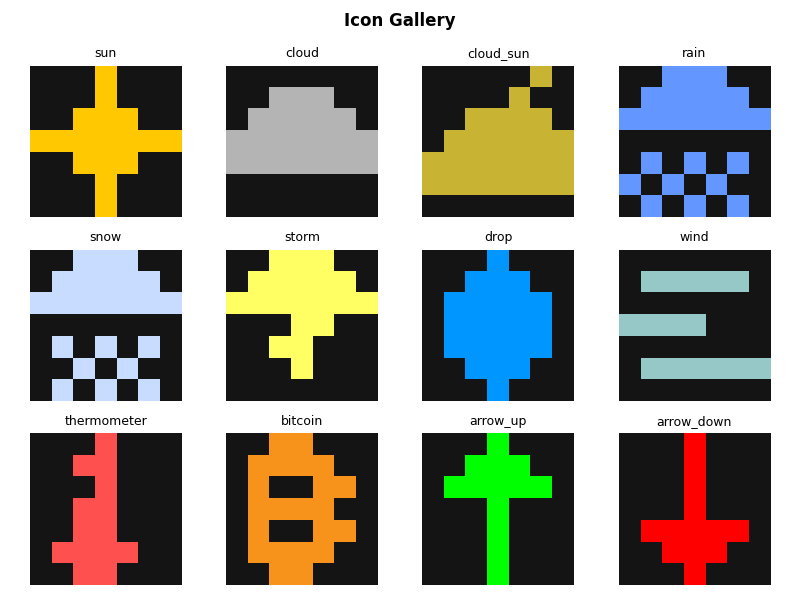

In [4]:
icon_names = list(ICONS.keys())
ncols = 4
nrows = (len(icon_names) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 2 * nrows))
axes = axes.flatten()

colors = {
    "sun": (255, 200, 0),
    "cloud": (180, 180, 180),
    "cloud_sun": (200, 180, 50),
    "rain": (100, 150, 255),
    "snow": (200, 220, 255),
    "storm": (255, 255, 100),
    "drop": (0, 150, 255),
    "wind": (150, 200, 200),
    "thermometer": (255, 80, 80),
    "bitcoin": (247, 147, 26),
    "arrow_up": (0, 255, 0),
    "arrow_down": (255, 0, 0),
}

for i, name in enumerate(icon_names):
    canvas = np.zeros((7, 7, 3), dtype=np.uint8)
    canvas[:] = (20, 20, 20)
    bitmap = ICONS[name]
    color = colors.get(name, (255, 255, 255))
    for y, row in enumerate(bitmap):
        for x, ch in enumerate(row):
            if ch == "1":
                canvas[y, x] = color
    axes[i].imshow(canvas, interpolation="nearest")
    axes[i].set_title(name, fontsize=9)
    axes[i].axis("off")

for i in range(len(icon_names), len(axes)):
    axes[i].axis("off")

fig.suptitle("Icon Gallery", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## Elements

Building blocks: `IconElement`, `TextElement`, `BarElement`, `RectElement`.

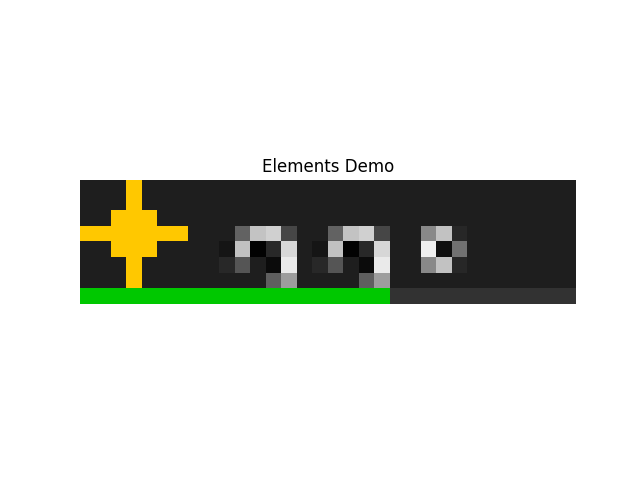

In [5]:
screen = Screen(
    "elements_demo",
    [
        RectElement(0, 0, W, H, color=(30, 30, 30)),
        IconElement(0, 0, 8, 8, icon="sun", color=(255, 200, 0)),
        TextElement(9, 1, 20, 7, text="22\u00b0", color=(255, 255, 255)),
        BarElement(0, 7, W, 1, value=0.65, color=(0, 200, 0), bg=(50, 50, 50)),
    ],
)

fig, ax = plt.subplots()
ax.imshow(screen.render(W, H), interpolation="nearest")
ax.set_title("Elements Demo")
ax.axis("off")
plt.show()

## Plugin Snapshots

Single-frame preview of every plugin.

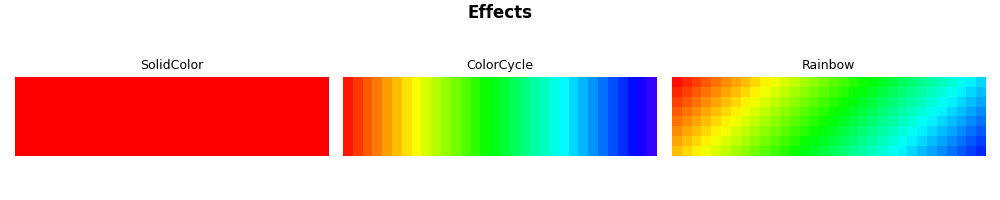

In [6]:
plugins = {
    "SolidColor": SolidColor({"color": [255, 0, 0]}, W, H),
    "ColorCycle": ColorCycle({"speed": 5}, W, H),
    "Rainbow": Rainbow({"speed": 3}, W, H),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
for ax, (name, plugin) in zip(axes, plugins.items(), strict=True):
    plugin.tick()
    ax.imshow(plugin.render(), interpolation="nearest")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
fig.suptitle("Effects", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

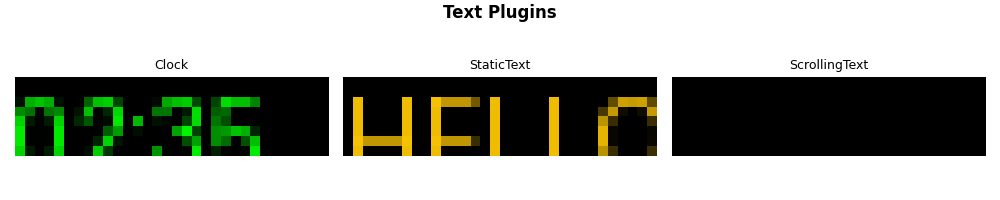

In [7]:
plugins = {
    "Clock": Clock({"color": [0, 255, 0]}, W, H),
    "StaticText": StaticText({"text": "HELLO", "color": [255, 200, 0]}, W, H),
    "ScrollingText": ScrollingText({"text": "LED WALL", "color": [0, 200, 255]}, W, H),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
for ax, (name, plugin) in zip(axes, plugins.items(), strict=True):
    plugin.tick()
    ax.imshow(plugin.render(), interpolation="nearest")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
fig.suptitle("Text Plugins", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

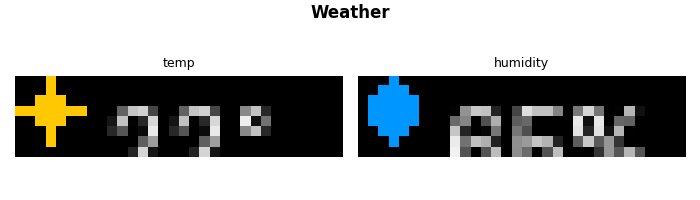

In [8]:
weather = Weather({"screen_mode": "fixed"}, W, H)
weather._temp = "22"
weather._humidity = "65"
weather._weather_code = 0
weather._fetched = True
weather.screen_manager.screens = weather._build_screens()

fig, axes = plt.subplots(1, 2, figsize=(7, 2))
for i, ax in enumerate(axes):
    ax.imshow(weather.screen_manager.screens[i].render(W, H), interpolation="nearest")
    ax.set_title(weather.screen_manager.screens[i].name, fontsize=9)
    ax.axis("off")
fig.suptitle("Weather", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

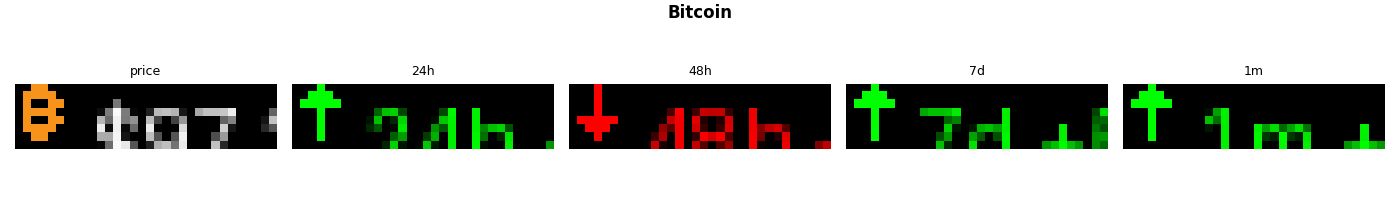

In [9]:
btc = Bitcoin({"screen_mode": "fixed"}, W, H)
btc._price = 97200.0
btc._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc._fetched = True
btc.screen_manager.screens = btc._build_screens()

screens = btc.screen_manager.screens
fig, axes = plt.subplots(1, len(screens), figsize=(14, 2))
for ax, screen in zip(axes, screens, strict=True):
    ax.imshow(screen.render(W, H), interpolation="nearest")
    ax.set_title(screen.name, fontsize=9)
    ax.axis("off")
fig.suptitle("Bitcoin", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## Animated Previews

Live animations using `LedWallVisualizer`. Each cell creates an interactive animation.

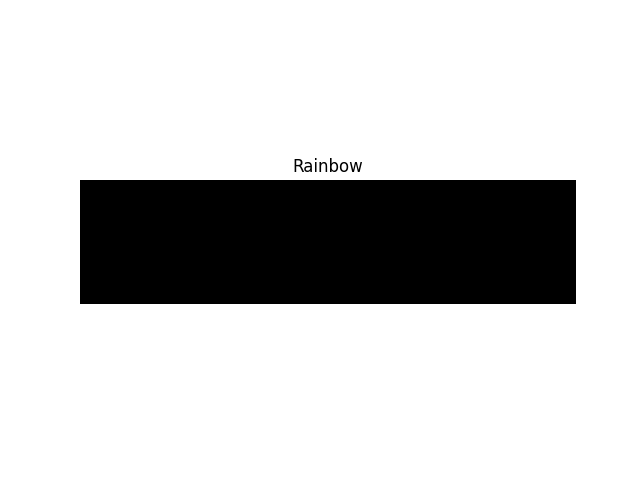

In [10]:
viz.preview_plugin(Rainbow({"speed": 3}, W, H), frames=200)

/Users/giorgiocaizzi/Documents/github/picow-ws2812/.venv/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


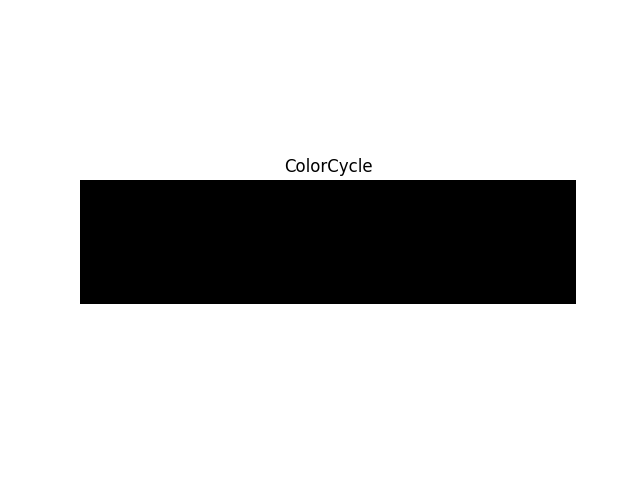

In [11]:
viz.preview_plugin(ColorCycle({"speed": 5}, W, H), frames=200)

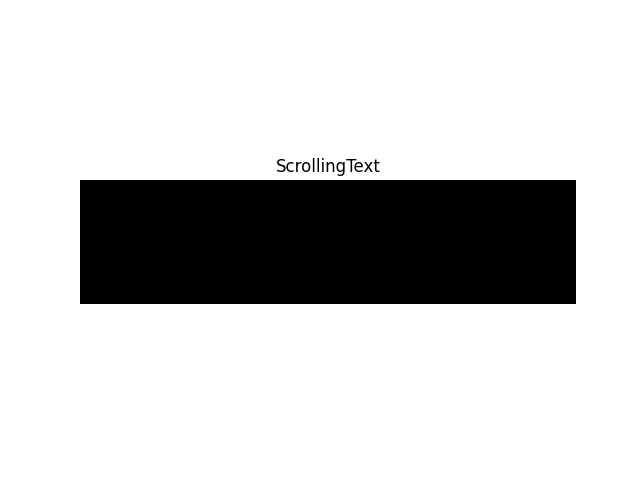

In [12]:
viz.preview_plugin(
    ScrollingText({"text": "LED WALL", "color": [0, 200, 255]}, W, H), frames=200
)

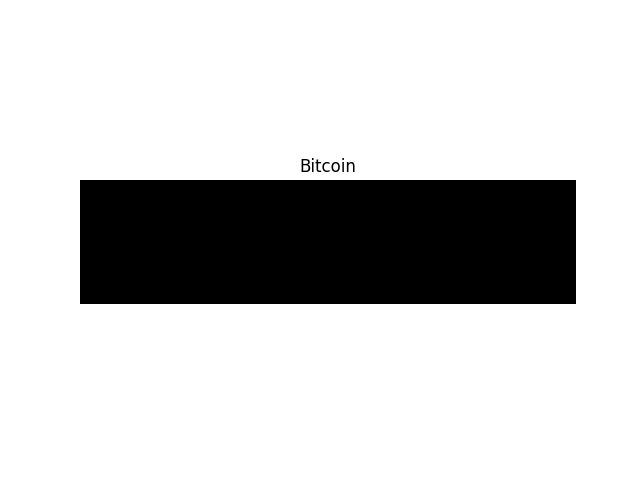

In [13]:
btc_anim = Bitcoin({"screen_mode": "auto", "screen_interval": 60}, W, H)
btc_anim._price = 97200.0
btc_anim._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc_anim._fetched = True
btc_anim.screen_manager.screens = btc_anim._build_screens()

viz.preview_plugin(btc_anim, frames=400)

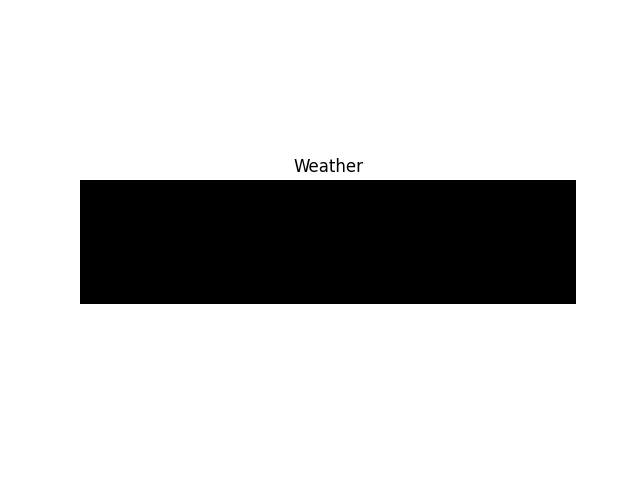

In [14]:
weather_anim = Weather({"screen_mode": "auto", "screen_interval": 60}, W, H)
weather_anim._temp = "22"
weather_anim._humidity = "65"
weather_anim._weather_code = 0
weather_anim._fetched = True
weather_anim.screen_manager.screens = weather_anim._build_screens()

viz.preview_plugin(weather_anim, frames=200)

## Composed Scenes

Multiple plugins composited into a single frame using `Renderer`.

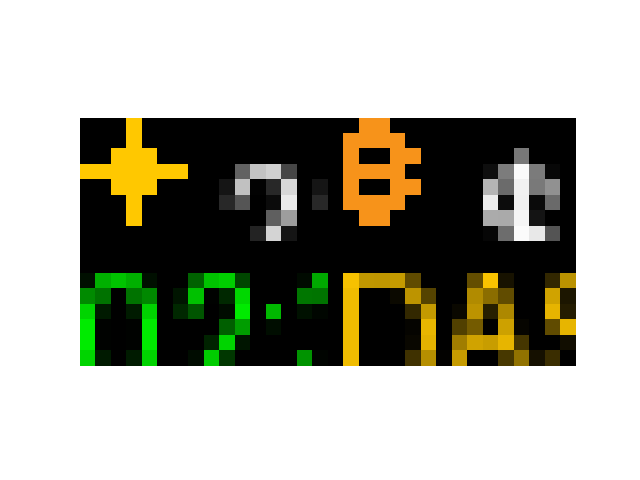

In [15]:
scene_w, scene_h = 32, 16
renderer = Renderer(scene_w, scene_h)

weather_dash = Weather({"screen_mode": "fixed"}, 16, 8)
weather_dash._temp = "22"
weather_dash._humidity = "65"
weather_dash._weather_code = 0
weather_dash._fetched = True
weather_dash.screen_manager.screens = weather_dash._build_screens()

btc_dash = Bitcoin({"screen_mode": "fixed"}, 16, 8)
btc_dash._price = 97200.0
btc_dash._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc_dash._fetched = True
btc_dash.screen_manager.screens = btc_dash._build_screens()

layers = [
    (weather_dash, 0, 0),
    (btc_dash, 16, 0),
    (Clock({"color": [0, 255, 0]}, 16, 8), 0, 8),
    (StaticText({"text": "DASH", "color": [255, 200, 0]}, 16, 8), 16, 8),
]

scene_viz = LedWallVisualizer(width=scene_w, height=scene_h)
scene_viz.snapshot(renderer=renderer, layers=layers)

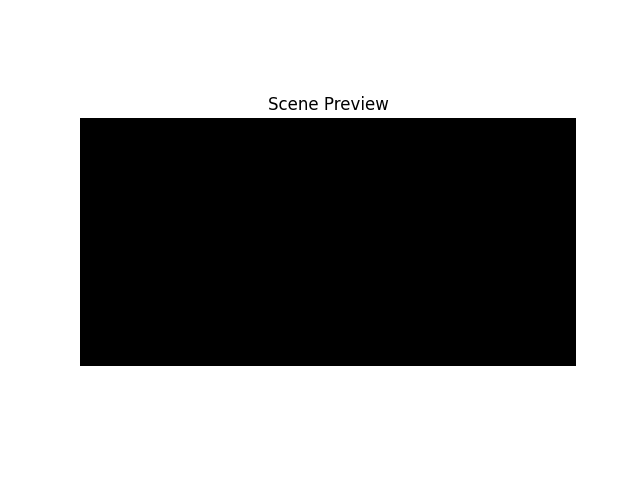

In [16]:
scene_w, scene_h = 32, 16
renderer = Renderer(scene_w, scene_h)

weather_live = Weather({"screen_mode": "auto", "screen_interval": 60}, 16, 8)
weather_live._temp = "22"
weather_live._humidity = "65"
weather_live._weather_code = 0
weather_live._fetched = True
weather_live.screen_manager.screens = weather_live._build_screens()

btc_live = Bitcoin({"screen_mode": "auto", "screen_interval": 60}, 16, 8)
btc_live._price = 97200.0
btc_live._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc_live._fetched = True
btc_live.screen_manager.screens = btc_live._build_screens()

layers = [
    (weather_live, 0, 0),
    (btc_live, 16, 0),
    (Clock({"color": [0, 255, 0]}, 16, 8), 0, 8),
    (ScrollingText({"text": "LED WALL", "color": [255, 200, 0]}, 16, 8), 16, 8),
]

scene_viz = LedWallVisualizer(width=scene_w, height=scene_h)
scene_viz.preview_scene(renderer, layers, frames=400)